**Step 1: Setup & Load**

In [14]:
import shap
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("Outputs/shap_explainability", exist_ok=True)

print("Loading ml_dataset_enhanced.csv...")
df = pd.read_csv("Outputs/feature_engineering/ml_dataset_enhanced.csv")
df["earnings_date"] = pd.to_datetime(df["earnings_date"])
print(f"      Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nLoading selected features...")
selected_features = pd.read_csv(
    "Outputs/classification/selected_features.csv")['selected_features'].tolist()
print(f"      {len(selected_features)} features loaded")

print("\nReconstructing train / test split...")
IDENTITY_COLS = ["ticker", "earnings_date", "q"]
LABEL_COLS    = ["label_5d", "label_10d", "label_20d"]
LEAKAGE_COLS  = ["return_5d", "return_10d", "return_20d"]
DROP_COLS     = ["industry", "close", "fifty_two_wk_high", "fifty_two_wk_low"]
ALL_DROP      = IDENTITY_COLS + LABEL_COLS + LEAKAGE_COLS + DROP_COLS

train_df = df[df["earnings_date"].dt.year.isin([2019, 2020, 2021])].copy()
test_df  = df[df["earnings_date"].dt.year.isin([2022, 2023])].copy()

train_df["price_position_52w"] = train_df["price_position_52w"].clip(0, 1)
test_df["price_position_52w"]  = test_df["price_position_52w"].clip(0, 1)

train_df = pd.get_dummies(train_df, columns=["sector"], drop_first=True, dtype=int)
test_df  = pd.get_dummies(test_df,  columns=["sector"], drop_first=True, dtype=int)
test_df  = test_df.reindex(columns=train_df.columns, fill_value=0)

X_train_full = train_df.drop(columns=[c for c in ALL_DROP if c in train_df.columns])
X_test_full  = test_df.drop(columns=[c for c in ALL_DROP if c in test_df.columns])
y_test       = test_df["label_5d"].astype(int)

X_train = X_train_full[selected_features]
X_test  = X_test_full[selected_features]

print(f"      X_train: {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"      X_test:  {X_test.shape[0]:,} rows  × {X_test.shape[1]} features")

print("\nLoading best model...")
with open("Outputs/classification/best_model.pkl", "rb") as f:
    model = pickle.load(f)
print(f"      Model loaded: {type(model).__name__}")

Loading ml_dataset_enhanced.csv...
      Loaded: 13,803 rows × 68 columns

Loading selected features...
      48 features loaded

Reconstructing train / test split...
      X_train: 10,184 rows × 48 features
      X_test:  3,387 rows  × 48 features

Loading best model...
      Model loaded: RandomForestClassifier


**Step 2: Compute SHAP Values**

In [15]:
print("Sampling 1,000 rows from test set for SHAP...")
X_shap = X_test.sample(min(1000, len(X_test)), random_state=42)
print(f"      X_shap shape: {X_shap.shape}")

print("\nInitialising TreeExplainer...")
explainer = shap.TreeExplainer(model)
print("      TreeExplainer ready ✓")

print("\nComputing SHAP values on sample...")
shap_values = explainer.shap_values(X_shap)

# handle both old and new SHAP versions
if isinstance(shap_values, list):
    # older SHAP: returns list [class_0, class_1]
    shap_vals = shap_values[1]
    print("      SHAP version: list format → using shap_values[1]")
else:
    # newer SHAP (0.45+): returns array (n_samples, n_features, n_classes)
    shap_vals = shap_values[:, :, 1]
    print("      SHAP version: array format → using shap_values[:, :, 1]")

print(f"      SHAP values shape: {shap_vals.shape}")

# handle both old and new expected_value format
base_value = (
    explainer.expected_value[1]
    if np.ndim(explainer.expected_value) > 0
    else explainer.expected_value
)
print(f"      Base value (expected prediction): {base_value:.4f}")

# mean absolute SHAP per feature
mean_abs_shap = pd.DataFrame({
    'feature'   : X_shap.columns,
    'mean_shap' : np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print(f"\n      Top 15 features by mean |SHAP|:")
print(f"      {'Rank':<6} {'Feature':<40} {'Mean |SHAP|'}")
print(f"      {'----':<6} {'-------':<40} {'----------'}")
for i, row in mean_abs_shap.head(15).iterrows():
    print(f"      {i+1:<6} {row['feature']:<40} {row['mean_shap']:.5f}")

Sampling 1,000 rows from test set for SHAP...
      X_shap shape: (1000, 48)

Initialising TreeExplainer...
      TreeExplainer ready ✓

Computing SHAP values on sample...
      SHAP version: array format → using shap_values[:, :, 1]
      SHAP values shape: (1000, 48)
      Base value (expected prediction): 0.4999

      Top 15 features by mean |SHAP|:
      Rank   Feature                                  Mean |SHAP|
      ----   -------                                  ----------
      1      price_position_52w                       0.01805
      2      eps_forward                              0.00866
      3      revenue                                  0.00653
      4      qa_sentiment                             0.00595
      5      return_on_equity                         0.00479
      6      momentum_10d                             0.00437
      7      market_cap                               0.00432
      8      log_market_cap                           0.00426
      9      gros

**Step 3: Global Feature Importance**

Plotting global bar chart (top 20 features)...


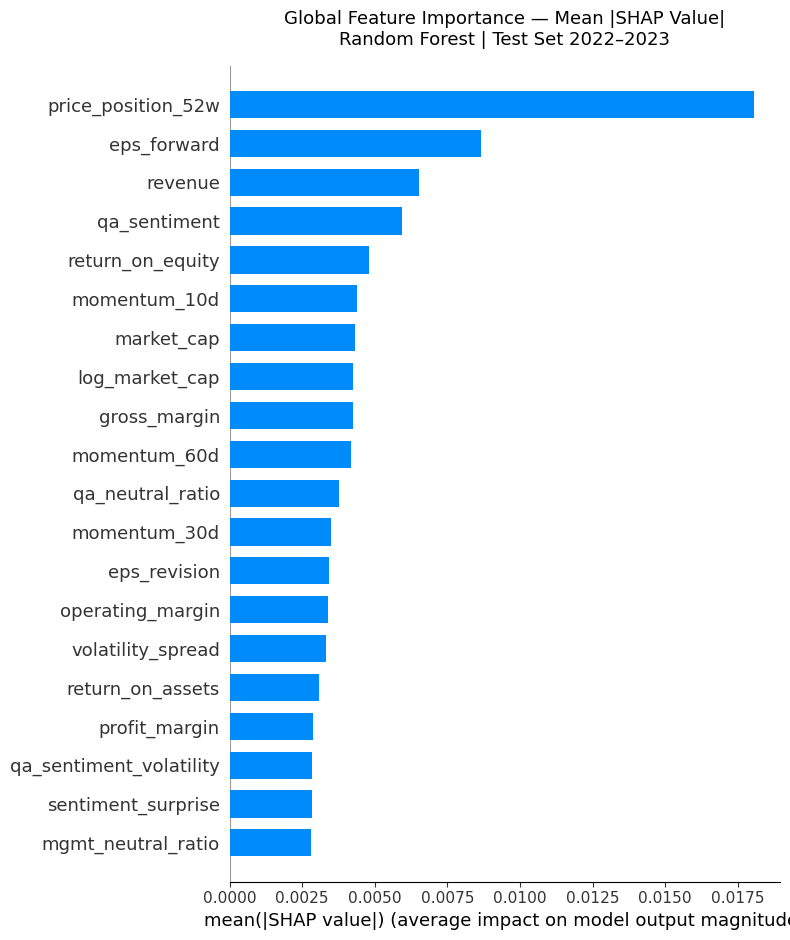

      Saved → Outputs/shap_explainability/shap_global_bar.png

Plotting beeswarm plot (top 20 features)...


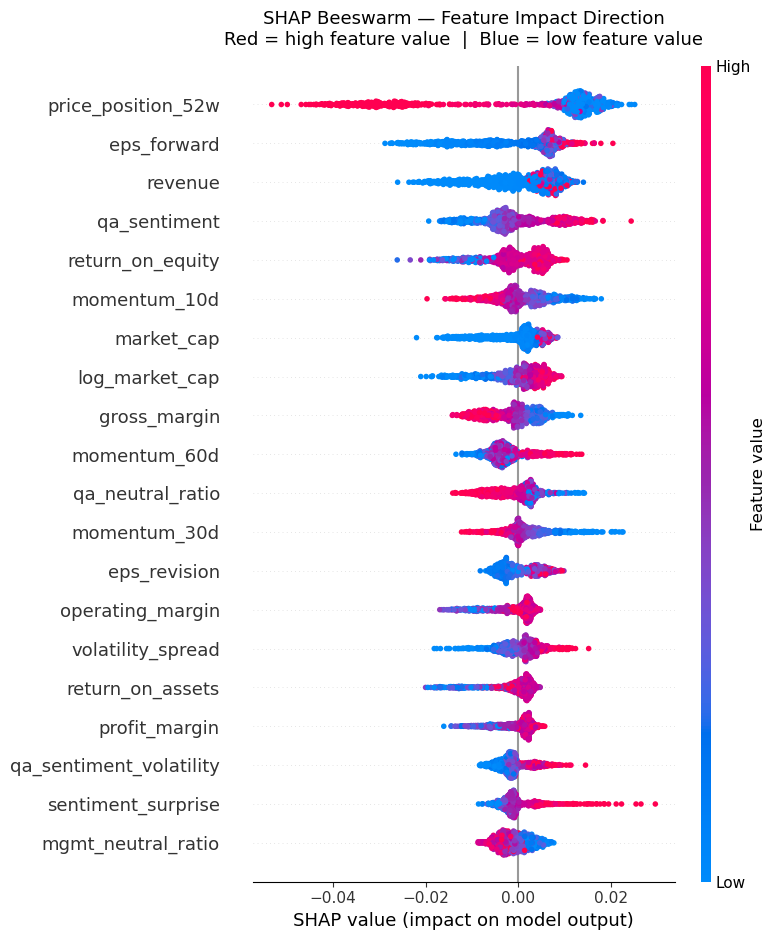

      Saved → Outputs/shap_explainability/shap_beeswarm.png

Plotting dependence plots (key sentiment features)...


<Figure size 800x500 with 0 Axes>

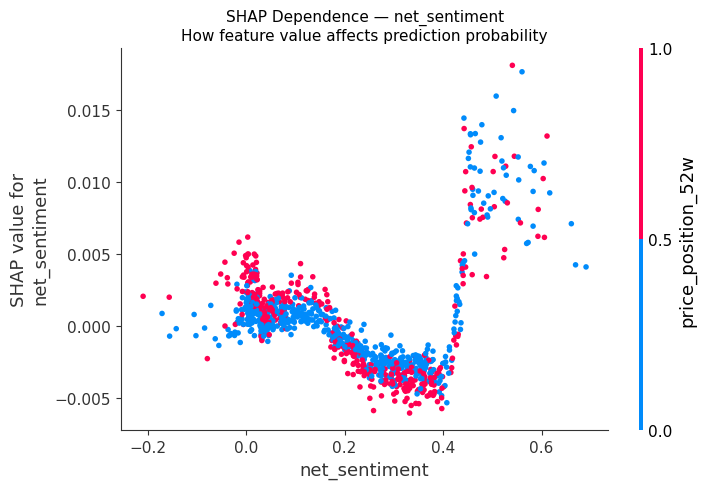

      Saved → Outputs/shap_explainability/shap_dependence_net_sentiment.png


<Figure size 800x500 with 0 Axes>

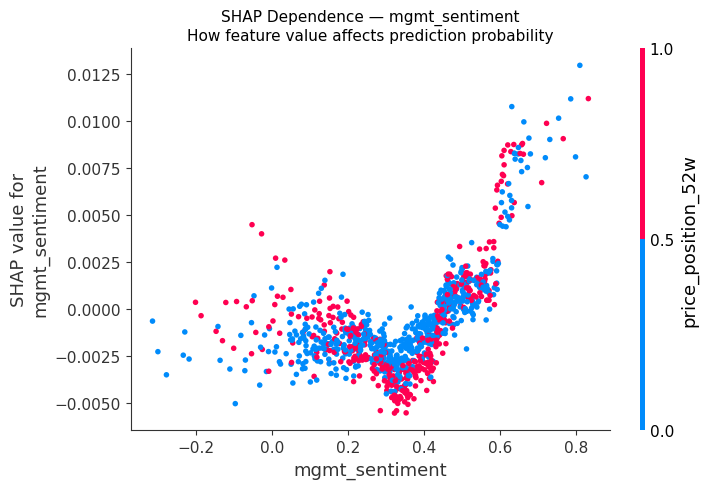

      Saved → Outputs/shap_explainability/shap_dependence_mgmt_sentiment.png


<Figure size 800x500 with 0 Axes>

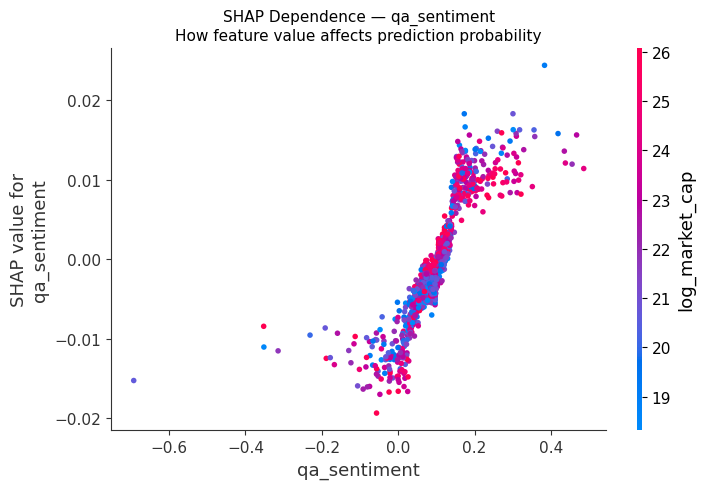

      Saved → Outputs/shap_explainability/shap_dependence_qa_sentiment.png


<Figure size 800x500 with 0 Axes>

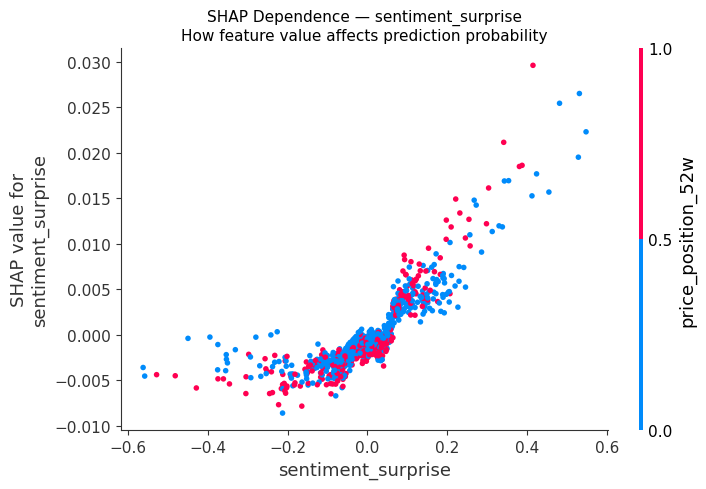

      Saved → Outputs/shap_explainability/shap_dependence_sentiment_surprise.png


<Figure size 800x500 with 0 Axes>

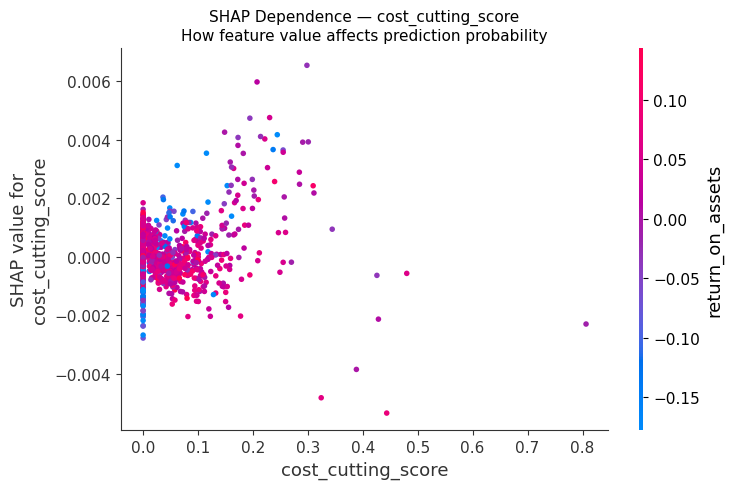

      Saved → Outputs/shap_explainability/shap_dependence_cost_cutting_score.png


In [16]:
# ── 3a. Bar plot ───────────────────────────────────────────────
print("Plotting global bar chart (top 20 features)...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals, X_shap,
    plot_type='bar', max_display=20, show=False
)
plt.title("Global Feature Importance — Mean |SHAP Value|\n"
          "Random Forest | Test Set 2022–2023", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("Outputs/shap_explainability/shap_global_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("      Saved → Outputs/shap_explainability/shap_global_bar.png")

# ── 3b. Beeswarm plot ──────────────────────────────────────────
print("\nPlotting beeswarm plot (top 20 features)...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals, X_shap,
    plot_type='dot', max_display=20, show=False
)
plt.title("SHAP Beeswarm — Feature Impact Direction\n"
          "Red = high feature value  |  Blue = low feature value",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("Outputs/shap_explainability/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("      Saved → Outputs/shap_explainability/shap_beeswarm.png")

# ── 3c. Dependence plot ──────────────────────────────────────────
# manually specify business-relevant sentiment features for dependence plots
# top-5 by SHAP may pick market_cap, revenue etc. which are less interesting
print("\nPlotting dependence plots (key sentiment features)...")
important_business_features = [
    'net_sentiment',
    'mgmt_sentiment',
    'qa_sentiment',
    'sentiment_surprise',
    'cost_cutting_score',
]

# keep only those that exist in X_shap
important_business_features = [
    f for f in important_business_features if f in X_shap.columns
]

for feat in important_business_features:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feat, shap_vals, X_shap, show=False)
    plt.title(f"SHAP Dependence — {feat}\n"
              "How feature value affects prediction probability", fontsize=11)
    plt.tight_layout()
    safe_name = feat.replace(" ", "_").replace("/", "_")
    plt.savefig(f"Outputs/shap_explainability/shap_dependence_{safe_name}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"      Saved → Outputs/shap_explainability/shap_dependence_{safe_name}.png")

**Global Feature Importance**: `price_position_52w` emerged as the single most important feature (mean |SHAP| = 0.01805), more than double the next feature, indicating that a stock's position within its 52-week trading range is the strongest pre-earnings signal for short-term directional prediction. 

**Dependence Plot Findings**: positive `sentiment_surprise` (actual sentiment exceeding prior quarter) consistently pushes predictions toward UP, while high `qa_sentiment` combined with large market capitalisation amplifies the positive effect. `net_sentiment` shows a non-linear relationship, with impact accelerates above 0.4. `cost_cutting_score` has mixed effects depending on profitability context (`return_on_assets`) and `mgmt_sentiment` only becomes strongly predictive above 0.6 threshold


**Step 4: Feature Group Analysis**

Feature group breakdown:
    Sentiment     14 features  |  Mean total |SHAP| = 0.03003
    Market         9 features  |  Mean total |SHAP| = 0.04102
    Financial     14 features  |  Mean total |SHAP| = 0.05207
    Sector        11 features  |  Mean total |SHAP| = 0.00439

  Group contribution as % of total SHAP:
    Financial    40.8%
    Market       32.2%
    Sentiment    23.5%
    Sector       3.4%

Plotting feature group contribution chart...


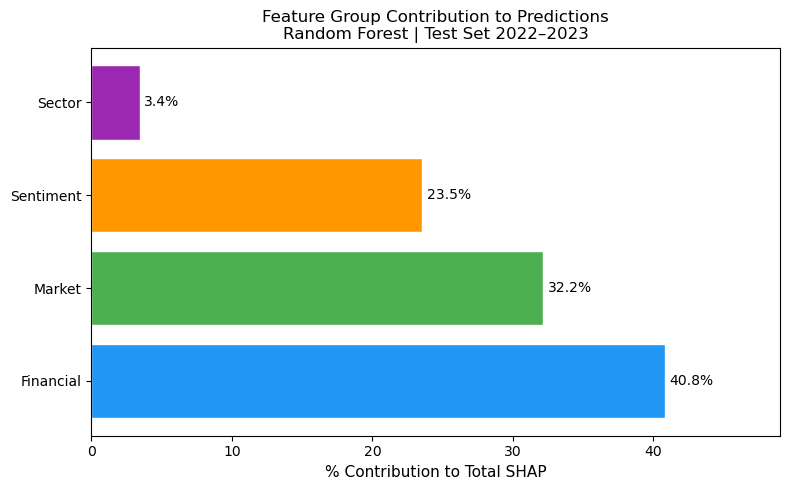

      Saved → Outputs/shap_explainability/shap_group_contribution.png

Top 10 sentiment features by mean |SHAP|:
  Rank   Sentiment Feature                   Mean |SHAP|
  ----   ------------------                  ----------
  1      qa_sentiment                        0.00595
  2      qa_neutral_ratio                    0.00376
  3      qa_sentiment_volatility             0.00283
  4      sentiment_surprise                  0.00283
  5      mgmt_neutral_ratio                  0.00280
  6      net_sentiment                       0.00256
  7      mgmt_sentiment                      0.00221
  8      qa_negative_ratio                   0.00144
  9      negative_ratio                      0.00141
  10     risk_score                          0.00095


In [17]:
SENTIMENT_FEATURES = [f for f in selected_features if f in [
    'net_sentiment', 'negative_ratio', 'mgmt_sentiment', 'mgmt_neutral_ratio',
    'mgmt_sentiment_volatility', 'qa_sentiment', 'qa_negative_ratio',
    'qa_neutral_ratio', 'qa_sentiment_volatility', 'confidence_score',
    'risk_score', 'uncertainty_score', 'cost_cutting_score', 'sentiment_surprise'
]]

MARKET_FEATURES = [f for f in selected_features if f in [
    'momentum_5d', 'momentum_10d', 'momentum_30d', 'momentum_60d',
    'volatility_10d', 'volatility_30d', 'volatility_spread',
    'risk_adjusted_momentum_30d', 'price_position_52w'
]]

SECTOR_FEATURES  = [f for f in selected_features if f.startswith('sector_')]
FINANCIAL_FEATURES = [f for f in selected_features
                      if f not in SENTIMENT_FEATURES + MARKET_FEATURES
                      + SECTOR_FEATURES]

groups = {
    'Sentiment' : SENTIMENT_FEATURES,
    'Market'    : MARKET_FEATURES,
    'Financial' : FINANCIAL_FEATURES,
    'Sector'    : SECTOR_FEATURES,
}

print(f"Feature group breakdown:")
group_shap = {}
for group, feats in groups.items():
    indices           = [list(X_shap.columns).index(f) for f in feats
                        if f in X_shap.columns]
    group_shap_val    = np.abs(shap_vals[:, indices]).sum(axis=1).mean()
    group_shap[group] = group_shap_val
    print(f"    {group:<12} {len(feats):>3} features  |  "
          f"Mean total |SHAP| = {group_shap_val:.5f}")

total_shap = sum(group_shap.values())
print(f"\n  Group contribution as % of total SHAP:")
for group, val in sorted(group_shap.items(), key=lambda x: x[1], reverse=True):
    pct = val / total_shap * 100
    print(f"    {group:<12} {pct:.1f}%")

# ── group bar chart ───────────────────────────────────────────────
print("\nPlotting feature group contribution chart...")
sorted_groups = sorted(group_shap.items(), key=lambda x: x[1], reverse=True)
group_names = [g[0] for g in sorted_groups]
group_pcts  = [g[1] / total_shap * 100 for g in sorted_groups]
colors      = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(group_names, group_pcts, color=colors, edgecolor='white')
ax.set_xlabel("% Contribution to Total SHAP", fontsize=11)
ax.set_title("Feature Group Contribution to Predictions\n"
             "Random Forest | Test Set 2022–2023", fontsize=12)
for bar, val in zip(bars, group_pcts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, max(group_pcts) * 1.2)
plt.tight_layout()
plt.savefig("Outputs/shap_explainability/shap_group_contribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("      Saved → Outputs/shap_explainability/shap_group_contribution.png")

# ── sentiment-only feature importance table ────────────────────────
print("\nTop 10 sentiment features by mean |SHAP|:")
sentiment_only = mean_abs_shap[
    mean_abs_shap['feature'].isin(SENTIMENT_FEATURES)
].reset_index(drop=True)

print(f"  {'Rank':<6} {'Sentiment Feature':<35} {'Mean |SHAP|'}")
print(f"  {'----':<6} {'------------------':<35} {'----------'}")
for i, row in sentiment_only.head(10).iterrows():
    print(f"  {i+1:<6} {row['feature']:<35} {row['mean_shap']:.5f}")

**Central Thesis Validation**: sentiment features account for nearly a quarter of all predictive power even after controlling for financial and market factors, directly validating the central hypothesis of EarningsEdge that earnings call language contains incremental predictive information beyond what traditional financial metrics alone can provide.

**Sentiment Feature Insights**: Q&A section features dominate over management remarks — `qa_sentiment` ranks as the top sentiment feature (mean |SHAP| = 0.00595), followed by `qa_neutral_ratio`, `qa_sentiment_volatility`, and `sentiment_surprise`, while `mgmt_sentiment` ranks seventh, suggesting that the unscripted analyst Q&A section reveals more authentic signals about company health than prepared management statements.

**Step 5: Local Explanations**

Selected examples:
    Confident UP   — P(UP) = 0.6240   True = UP
    Confident DOWN — P(UP) = 0.2823   True = UP
    Borderline     — P(UP) = 0.5000   True = UP


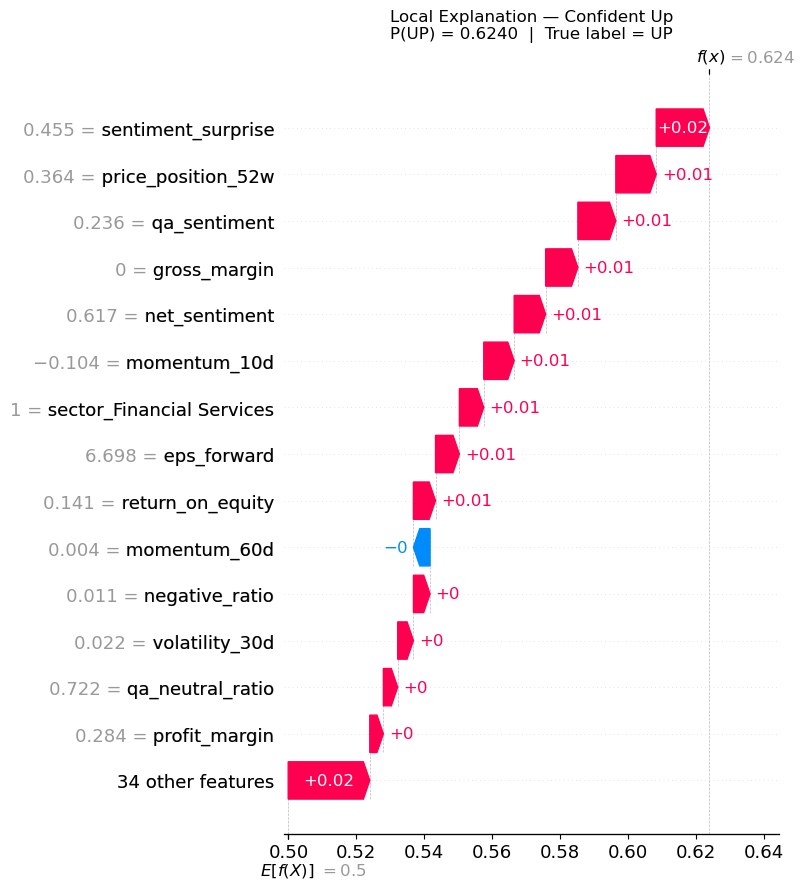


Saved → Outputs/shap_explainability/shap_waterfall_confident_up.png


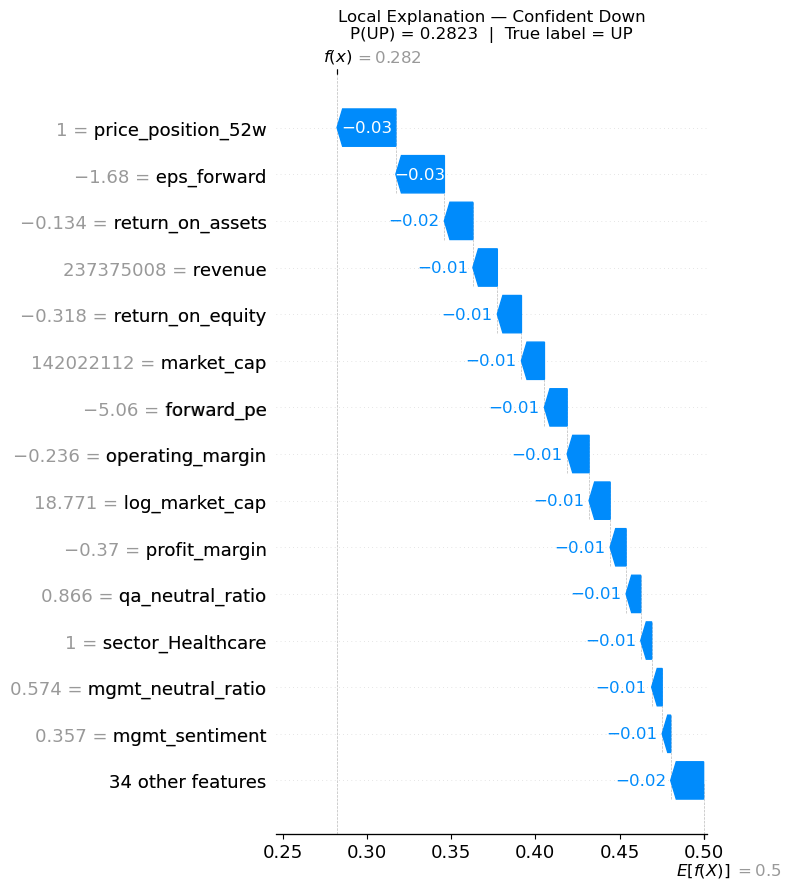


Saved → Outputs/shap_explainability/shap_waterfall_confident_down.png


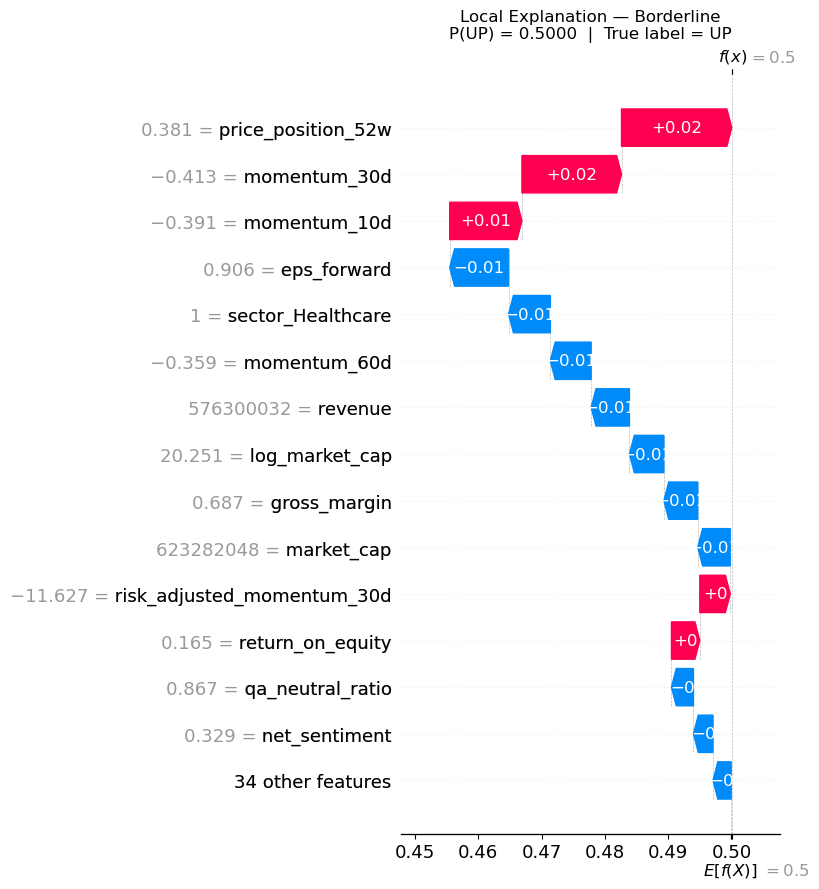


Saved → Outputs/shap_explainability/shap_waterfall_borderline.png


In [18]:
y_pred_proba = model.predict_proba(X_shap)[:, 1]
y_test_shap  = y_test.loc[X_shap.index]

# pick 3 representative examples
idx_up   = np.argmax(y_pred_proba)
idx_down = np.argmin(y_pred_proba)

# correct prediction closest to 0.5 (borderline but right)
correct_mask = (y_pred_proba > 0.5).astype(int) == y_test_shap.values
correct_idx  = np.where(correct_mask)[0]
idx_mid      = correct_idx[np.argmin(np.abs(y_pred_proba[correct_idx] - 0.5))]

cases = {
    'confident_up'   : idx_up,
    'confident_down' : idx_down,
    'borderline'     : idx_mid,
}

print(f"Selected examples:")
print(f"    Confident UP   — P(UP) = {y_pred_proba[idx_up]:.4f}   "
      f"True = {'UP' if y_test_shap.iloc[idx_up] == 1 else 'DOWN'}")
print(f"    Confident DOWN — P(UP) = {y_pred_proba[idx_down]:.4f}   "
      f"True = {'UP' if y_test_shap.iloc[idx_down] == 1 else 'DOWN'}")
print(f"    Borderline     — P(UP) = {y_pred_proba[idx_mid]:.4f}   "
      f"True = {'UP' if y_test_shap.iloc[idx_mid] == 1 else 'DOWN'}")

# version-safe Explanation object
shap_exp = shap.Explanation(
    values        = shap_vals,
    base_values   = base_value,
    data          = X_shap.values,
    feature_names = X_shap.columns.tolist()
)

for case_name, idx in cases.items():
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp[idx], max_display=15, show=False)
    plt.title(
        f"Local Explanation — {case_name.replace('_', ' ').title()}\n"
        f"P(UP) = {y_pred_proba[idx]:.4f}  |  "
        f"True label = {'UP' if y_test_shap.iloc[idx] == 1 else 'DOWN'}",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(f"Outputs/shap_explainability/shap_waterfall_{case_name}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved → Outputs/shap_explainability/shap_waterfall_{case_name}.png")

**Local Explanations**
- **Confident UP** (P(UP) = 0.6240, True = UP): driven by positive `sentiment_surprise` (0.455), positive `qa_sentiment` (0.236), and positive `net_sentiment` (0.617)
- **Confident DOWN** (P(UP) = 0.2823, True = UP): driven entirely by negative financial fundamentals — no sentiment features appeared as significant drivers
- **Borderline** (P(UP) = 0.5000, True = UP): `price_position_52w` pushed UP (+0.02) while multiple momentum and financial features cancelled each other out
- Sentiment adds signal primarily when fundamentals are neutral or ambiguous

**Step 6: Save Outputs**

In [19]:
# ── 6.1 top 20 features ──────────────────────────────────────────────────────
mean_abs_shap.head(20).to_csv(
    "Outputs/shap_explainability/shap_feature_importance.csv", index=False)
print("Saved → Outputs/shap_explainability/shap_feature_importance.csv  (Table 1)")

# ── 6.2 top 10 sentiment features ────────────────────────────────────────────
sentiment_only.head(10).to_csv(
    "Outputs/shap_explainability/sentiment_feature_importance.csv", index=False)
print("Saved → Outputs/shap_explainability/sentiment_feature_importance.csv  (Table 2)")

# ── 6.3 group contribution summary ───────────────────────────────────────────
group_summary = pd.DataFrame({
    'Group'           : list(group_shap.keys()),
    'N_features'      : [len(groups[g]) for g in group_shap.keys()],
    'Mean_SHAP'       : list(group_shap.values()),
    'Contribution_pct': [v / total_shap * 100 for v in group_shap.values()],
}).sort_values('Contribution_pct', ascending=False).reset_index(drop=True)

group_summary.to_csv("Outputs/shap_explainability/shap_group_summary.csv", index=False)
print("Saved → Outputs/shap_explainability/shap_group_summary.csv  (Table 3)")

# ── 6.4 raw SHAP values ──────────────────────────────────────────────────────
shap_df = pd.DataFrame(shap_vals, columns=X_shap.columns)
shap_df.to_csv("Outputs/shap_explainability/shap_values_test.csv", index=False)
print("Saved → Outputs/shap_explainability/shap_values_test.csv")

Saved → Outputs/shap_explainability/shap_feature_importance.csv  (Table 1)
Saved → Outputs/shap_explainability/sentiment_feature_importance.csv  (Table 2)
Saved → Outputs/shap_explainability/shap_group_summary.csv  (Table 3)
Saved → Outputs/shap_explainability/shap_values_test.csv


In [20]:
print("=" * 60)
print("PHASE 6 — SHAP EXPLAINABILITY COMPLETE")
print("=" * 60)
print(f"Model explained  : Random Forest (Baseline)")
print(f"SHAP sample      : {X_shap.shape[0]:,} rows")
print(f"Features         : {X_shap.shape[1]}")
print(f"\nFigures saved to Outputs/shap_explainability/:")
print(f"    Figure 1 — shap_global_bar.png")
print(f"    Figure 2 — shap_beeswarm.png")
print(f"    Figure 3 — shap_group_contribution.png")
print(f"    Figure 4 — shap_dependence_net_sentiment.png")
print(f"    Figure 5 — shap_dependence_sentiment_surprise.png")
print(f"    Figure 6 — shap_dependence_cost_cutting_score.png")
print(f"    Figure 7 — shap_waterfall_confident_up.png")
print(f"    Figure 8 — shap_waterfall_confident_down.png")
print(f"    Figure 9 — shap_waterfall_borderline.png")
print(f"\nTables saved to Outputs/shap_explainability/:")
print(f"    Table 1 — shap_feature_importance.csv     (top 20 features)")
print(f"    Table 2 — sentiment_feature_importance.csv (top 10 sentiment)")
print(f"    Table 3 — shap_group_summary.csv           (group contributions)")
print("=" * 60)

PHASE 6 — SHAP EXPLAINABILITY COMPLETE
Model explained  : Random Forest (Baseline)
SHAP sample      : 1,000 rows
Features         : 48

Figures saved to Outputs/shap_explainability/:
    Figure 1 — shap_global_bar.png
    Figure 2 — shap_beeswarm.png
    Figure 3 — shap_group_contribution.png
    Figure 4 — shap_dependence_net_sentiment.png
    Figure 5 — shap_dependence_sentiment_surprise.png
    Figure 6 — shap_dependence_cost_cutting_score.png
    Figure 7 — shap_waterfall_confident_up.png
    Figure 8 — shap_waterfall_confident_down.png
    Figure 9 — shap_waterfall_borderline.png

Tables saved to Outputs/shap_explainability/:
    Table 1 — shap_feature_importance.csv     (top 20 features)
    Table 2 — sentiment_feature_importance.csv (top 10 sentiment)
    Table 3 — shap_group_summary.csv           (group contributions)


**Phase 6 Complete**

**Method**
- Applied SHAP TreeExplainer to the final Random Forest model
- Evaluated on a representative sample of 1,000 observations from the 2022–2023 test set
- Explains both global feature importance and individual prediction decisions

**Key Takeaway**
- SHAP confirms that EarningsEdge integrates financial fundamentals, market momentum, and transcript sentiment into a coherent and interpretable investment signal framework
- The 23.5% sentiment contribution provides quantitative justification for NLP-based earnings call analysis in equity research


**Attach SHAP IDs**

In [22]:
# Attach ticker/earnings_date to shap_values_test.csv using X_shap already in memory.
# Uses X_shap.index directly - no re-sampling, no re-deriving anything, zero mismatch risk.

ids = df.loc[X_shap.index, ["ticker", "earnings_date"]].reset_index(drop=True)

shap_df = pd.DataFrame(shap_vals, columns=X_shap.columns)
shap_vals_with_ids = pd.concat([ids, shap_df], axis=1)

shap_vals_with_ids.to_csv("Outputs/shap_explainability/shap_values_test.csv", index=False)

print(f"Saved. New shape: {shap_vals_with_ids.shape}")
print(shap_vals_with_ids[["ticker", "earnings_date"]].head())

Saved. New shape: (1000, 50)
  ticker earnings_date
0     EL    2022-02-03
1   CLFD    2022-04-28
2    IRM    2022-08-04
3    FUL    2022-01-20
4    FHB    2022-07-29
